<a href="https://colab.research.google.com/github/kayokfds/trabalhoooo/blob/main/04_Estima%C3%A7%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dados estão no Google Drive, em FGV > TCC > Dados

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount("/content/drive")
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Mounted at /content/drive


In [2]:
caminho_dados = "/content/drive/MyDrive/FGV/TCC/Dados/Brutos"
caminho_output = "/content/drive/MyDrive/FGV/TCC/Dados"

In [3]:
DATA_INICIAL, DATA_FINAL = pd.to_datetime('2016-01-01'), pd.to_datetime('2025-12-31')

##Leitura de Todos Dados

In [4]:
dados_acoes = pd.read_csv(f"{caminho_output}/dados_acoes.csv")
dados_acoes = dados_acoes.iloc[:,1:]
dados_acoes = dados_acoes.rename(columns={'data': 'data_referencia'})
dados_acoes['data_referencia'] = pd.to_datetime(dados_acoes['data_referencia'])
print(dados_acoes.shape)
print(dados_acoes.dtypes)
dados_acoes.head()

(2225375, 16)
data_referencia    datetime64[ns]
codbdi                      int64
codneg                     object
tpmerc                      int64
nomres                     object
especi                     object
preabe                    float64
premax                    float64
premin                    float64
premed                    float64
preult                    float64
totneg                      int64
quatot                      int64
voltot                      int64
fatcot                      int64
origem                      int64
dtype: object


,data_referencia,codbdi,codneg,tpmerc,nomres,especi,preabe,premax,premin,premed,preult,totneg,quatot,voltot,fatcot,origem
0,2025-01-20,12,ITIP11,10,FII INTER IP,CI,69.00,69.24,68.08,68.30,68.39,59,1125,7684751,1,25
1,2025-01-20,12,ITIT11,10,FII INTER IT,CI,67.05,67.06,66.78,66.99,67.01,43,1686,11295441,1,25
2,2025-01-20,34,ITLC34,10,INTEL,DRN,21.52,22.93,21.52,22.47,22.61,2020,145538,327059441,1,25
3,2025-01-20,12,ITRI11,10,FII ITRI,CI,66.65,67.38,66.26,66.69,66.71,2518,17546,117022090,1,25
4,2025-01-20,2,ITSA3,10,ITAUSA,ON N1,9.20,9.34,9.14,9.26,9.31,372,98000,90797800,1,25


In [5]:
dados_macro = pd.read_csv((f"{caminho_output}/dados_macro.csv"))
dados_macro = dados_macro.iloc[:,1:]
dados_macro['data_referencia'] = pd.to_datetime(dados_macro['data_referencia'])
dados_macro = dados_macro[(dados_macro['data_referencia'] >= DATA_INICIAL) & (dados_macro['data_referencia'] <= DATA_FINAL)]
print(dados_macro.shape)
print(dados_macro.dtypes)
dados_macro.tail()

(2510, 8)
data_referencia    datetime64[ns]
selic                     float64
2520_du                   float64
504_du                    float64
252_du                    float64
126_du                    float64
63_du                     float64
cambio                    float64
dtype: object


,data_referencia,selic,2520_du,504_du,252_du,126_du,63_du,cambio
6526,2025-12-24,14.9,NaN,NaN,NaN,NaN,NaN,5.5350
6527,2025-12-26,14.9,13.588340,13.165333,13.7790,14.523,14.816,5.5413
6528,2025-12-29,14.9,13.573766,13.157571,13.8015,14.549,14.827,5.5739
6529,2025-12-30,14.9,13.518745,13.179429,13.8220,14.563,14.832,5.5024
6530,2025-12-31,14.9,NaN,NaN,NaN,NaN,NaN,5.5024


##Construindo DF

In [6]:
dados = pd.merge(dados_acoes, dados_macro, how = 'left', on='data_referencia')
dados = dados.sort_values(by=list(dados.columns))
print(dados.shape)
dados

(2225375, 23)


,data_referencia,codbdi,codneg,tpmerc,nomres,especi,preabe,premax,premin,premed,...,voltot,fatcot,origem,selic,2520_du,504_du,252_du,126_du,63_du,cambio
2115940,2016-01-04,2,AAPL34,10,APPLE,DRN,41.50,42.20,41.50,42.13,...,52664400,1,16,14.15,16.420130,16.501154,15.763429,15.224,14.750,4.0387
2115941,2016-01-04,2,ABCB4,10,ABC BRASIL,PN EJS N2,8.20,8.28,7.66,8.08,...,119705600,1,16,14.15,16.420130,16.501154,15.763429,15.224,14.750,4.0387
2115943,2016-01-04,2,ABEV3,10,AMBEV S/A,ON EJ,17.73,17.73,17.21,17.34,...,22913285600,1,16,14.15,16.420130,16.501154,15.763429,15.224,14.750,4.0387
2115944,2016-01-04,2,ABTT34,10,ABBOTT,DRN,43.20,43.20,43.20,43.20,...,10800000,1,16,14.15,16.420130,16.501154,15.763429,15.224,14.750,4.0387
2115947,2016-01-04,2,AGRO3,10,BRASILAGRO,ON NM,11.03,11.03,10.94,10.99,...,51350500,1,16,14.15,16.420130,16.501154,15.763429,15.224,14.750,4.0387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335824,2025-12-30,36,IBIT39,10,BKR BITCOIN,DRE,91.82,92.90,91.00,91.77,...,78317966,1,25,14.90,13.518745,13.179429,13.822000,14.563,14.832,5.5024
335825,2025-12-30,36,SIVR39,10,ABDEN SILV,DRE,140.00,140.00,132.00,134.15,...,39641955,1,25,14.90,13.518745,13.179429,13.822000,14.563,14.832,5.5024
335831,2025-12-30,36,SOLN39,10,21SH SOLANA,DRE,45.00,45.26,45.00,45.14,...,18058,1,25,14.90,13.518745,13.179429,13.822000,14.563,14.832,5.5024
335832,2025-12-30,36,TBIL39,10,GX T BILL,DRE ED,58.50,58.74,58.49,58.61,...,7854425,1,25,14.90,13.518745,13.179429,13.822000,14.563,14.832,5.5024


In [7]:
## TRANSFORMANDO TODOS OS NOMES EM PADRÃO
dados = dados.sort_values('data_referencia')
nomes_acoes = dados.groupby('codneg')['nomres'].last()
nomes_acoes = {k: [v] for k, v in nomes_acoes.items()}
for i in nomes_acoes.keys():
  if len(nomes_acoes[i])!=1:
    print("PROBLEMA", i, nomes_acoes[i])


dados['nomres'] = dados['codneg'].map(
    {k: v[0] for k, v in nomes_acoes.items()}
)

##Checks

In [8]:
colunas = list(dados.columns)
print(colunas)

['data_referencia', 'codbdi', 'codneg', 'tpmerc', 'nomres', 'especi', 'preabe', 'premax', 'premin', 'premed', 'preult', 'totneg', 'quatot', 'voltot', 'fatcot', 'origem', 'selic', '2520_du', '504_du', '252_du', '126_du', '63_du', 'cambio']


###base_acoes

In [9]:
colunas_acoes = colunas[1:16]
print("Algum lugar tem dado vazio?:")
dados[dados[['data_referencia']+colunas_acoes].isna().any(axis=1)][['data_referencia']+colunas_acoes]

Algum lugar tem dado vazio?:


,data_referencia,codbdi,codneg,tpmerc,nomres,especi,preabe,premax,premin,premed,preult,totneg,quatot,voltot,fatcot,origem


###base_macro

In [10]:
colunas_macro = colunas[16:]
print("Algum lugar tem dado vazio?:")
print(list(dados[dados[['data_referencia']+colunas_macro].isna().any(axis=1)][['data_referencia']+colunas_macro]['data_referencia'].unique()))
dados[dados[['data_referencia']+colunas_macro].isna().any(axis=1)][['data_referencia']+colunas_macro]

Algum lugar tem dado vazio?:
[Timestamp('2018-05-25 00:00:00')]


,data_referencia,selic,2520_du,504_du,252_du,126_du,63_du,cambio
1926822,2018-05-25,6.4,NaN,NaN,NaN,NaN,NaN,3.6587
1926821,2018-05-25,6.4,NaN,NaN,NaN,NaN,NaN,3.6587
1926820,2018-05-25,6.4,NaN,NaN,NaN,NaN,NaN,3.6587
1926819,2018-05-25,6.4,NaN,NaN,NaN,NaN,NaN,3.6587
1926814,2018-05-25,6.4,NaN,NaN,NaN,NaN,NaN,3.6587
...,...,...,...,...,...,...,...,...
1926570,2018-05-25,6.4,NaN,NaN,NaN,NaN,NaN,3.6587
1926566,2018-05-25,6.4,NaN,NaN,NaN,NaN,NaN,3.6587
1926571,2018-05-25,6.4,NaN,NaN,NaN,NaN,NaN,3.6587
1926569,2018-05-25,6.4,NaN,NaN,NaN,NaN,NaN,3.6587


In [11]:
### ARRUMANDO DADOS PARA SPREAD : MÉDIA SIMPLES ENTRE OS DOIS DIAS MAIS PRÓXIMOS
print("DATAS PRÓXIMAS: ", list(dados[dados['data_referencia'].between(pd.to_datetime('2018-05-20'), pd.to_datetime('2018-05-30'))]['data_referencia'].unique()),"\n")

valores = dados[dados['data_referencia'].isin([pd.to_datetime('2018-05-24'),pd.to_datetime('2018-05-28')])].groupby('data_referencia')[['2520_du', '504_du', '252_du', '126_du', '63_du']].mean()

media = valores.mean()

dados.loc[
    dados['data_referencia'] == pd.to_datetime('2018-05-25'),
    ['2520_du', '504_du', '252_du', '126_du', '63_du']
] = media.values

print("Algum lugar tem dado vazio?:")
print(list(dados[dados[['data_referencia']+colunas_macro].isna().any(axis=1)][['data_referencia']+colunas_macro]['data_referencia'].unique()))
dados[dados[['data_referencia']+colunas_macro].isna().any(axis=1)][['data_referencia']+colunas_macro]

print("\n COMO FICOU: \n")

dados[(dados['data_referencia'] >= pd.to_datetime('2018-05-20')) & (dados['data_referencia'] <= pd.to_datetime('2018-05-30'))] \
.groupby('data_referencia')[['2520_du', '504_du', '252_du', '126_du', '63_du']] \
.agg(lambda x: list(x.unique()))


DATAS PRÓXIMAS:  [Timestamp('2018-05-21 00:00:00'), Timestamp('2018-05-22 00:00:00'), Timestamp('2018-05-23 00:00:00'), Timestamp('2018-05-24 00:00:00'), Timestamp('2018-05-25 00:00:00'), Timestamp('2018-05-28 00:00:00'), Timestamp('2018-05-29 00:00:00'), Timestamp('2018-05-30 00:00:00')] 

Algum lugar tem dado vazio?:
[]

 COMO FICOU: 



,2520_du,504_du,252_du,126_du,63_du
data_referencia,,,,,
2018-05-21,[11.025734693877553],[8.1282],[7.0456666666666665],[6.532],[6.456]
2018-05-22,[11.003061224489796],[7.965923076923077],[6.961714285714286],[6.517181818181818],[6.421799999999999]
2018-05-23,[11.00942857142857],[7.873],[6.861],[6.535818181818182],[6.442666666666667]
2018-05-24,[11.199714285714286],[7.9918571428571425],[6.9603636363636365],[6.5862],[6.4586250000000005]
2018-05-25,[11.350285714285716],[8.067256157635468],[7.053681818181818],[6.6381],[6.4828125]
2018-05-28,[11.500857142857145],[8.142655172413793],[7.146999999999999],[6.69],[6.507]
2018-05-29,[11.80769387755102],[8.220666666666666],[7.199714285714285],[6.714],[6.516333333333334]
2018-05-30,[11.84142857142857],[8.208275862068966],[7.229749999999999],[6.738],[6.536]


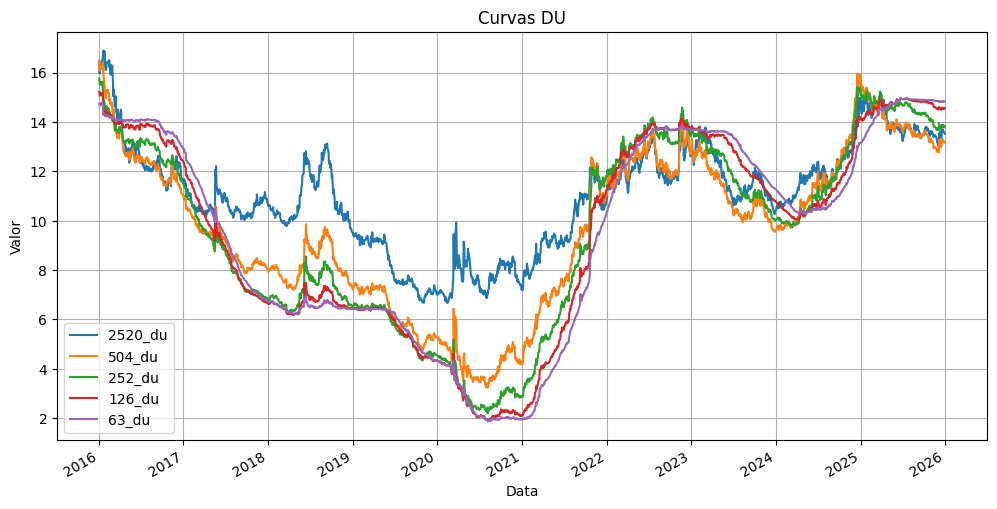

In [12]:
dados.groupby('data_referencia')[['2520_du', '504_du', '252_du', '126_du', '63_du']].first().plot(figsize=(12, 6))

plt.xlabel('Data')
plt.ylabel('Valor')
plt.title('Curvas DU')
plt.grid()
plt.show()

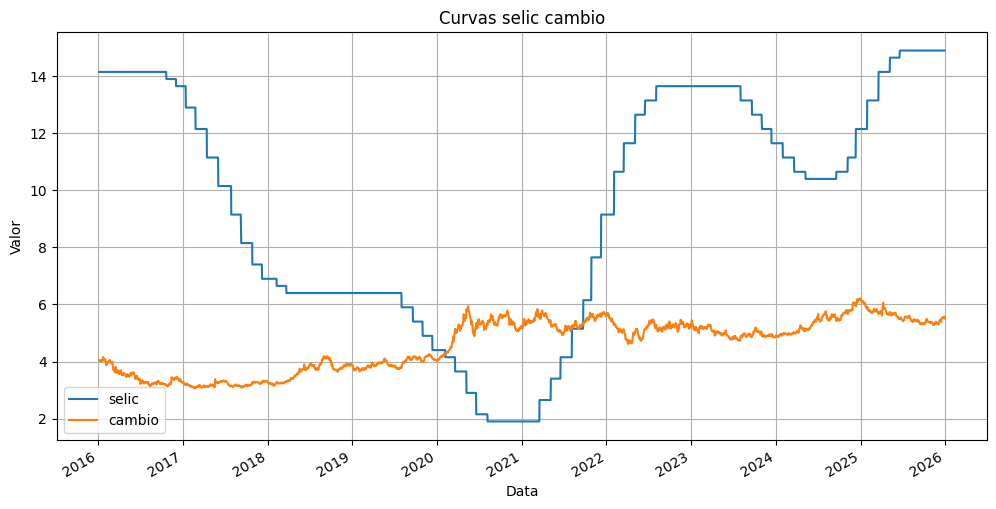

In [13]:
dados.groupby('data_referencia')[['selic','cambio']].first().plot(figsize=(12, 6))

plt.xlabel('Data')
plt.ylabel('Valor')
plt.title('Curvas selic cambio')
plt.grid()
plt.show()